In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_pb = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/benchmark/pacbio/output/qc_summary.tsv", sep='\t')
df_pb[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = df_pb['Sample'].str.split('-', expand=True)
#df_pb = df_pb.sort_values(['Donor', 'Tissue', 'Center'])
df_pb['Age'] = np.where(df_pb['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df_ont = pd.read_csv("/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/benchmark/ont/output/qc_summary.tsv", sep='\t')
df_ont[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = df_ont['Sample'].str.split('-', expand=True)
#df_ont = df_ont.sort_values(['Donor', 'Tissue', 'Center'])
df_ont['Age'] = np.where(df_ont['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

In [93]:
comb_numt_df = pd.DataFrame()

for sample in df_pb['Sample']:
    file_path = f'/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/benchmark/pacbio/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])

for sample in df_ont['Sample']:
    file_path = f'/net/nwgc/vol1/nobackup/czaka/mitoscope/smaht/benchmark/ont/output/{sample}/numts/{sample}.numts.INS.blast.mtDNA.txt'
    numt_df = pd.read_csv(file_path, sep='\t', header=None, names=['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore'])
    numt_df['Sample'] = sample
    comb_numt_df = pd.concat([comb_numt_df, numt_df])


comb_numt_df[['nchr', 'nstart']] = comb_numt_df['qseqid'].str.split('-', expand=True)
comb_numt_df['nstart'] = np.where(comb_numt_df['qstart'].astype(int) > 20, comb_numt_df['nstart'].astype(int) + comb_numt_df['qstart'].astype(int) - 1, comb_numt_df['nstart'].astype(int))
# comb_numt_df['nend'] = comb_numt_df['nstart'].astype(int) + comb_numt_df['length'].astype(int)
comb_numt_df['id'] = comb_numt_df['nchr'] + "-" + comb_numt_df['nstart'].astype(str)
comb_numt_df = comb_numt_df[comb_numt_df['nchr'] != 'chrM']

comb_numt_df = comb_numt_df[['id', 'length', 'Sample']]

comb_numt_df[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = comb_numt_df['Sample'].str.split('-', expand=True)
comb_numt_df['Donor+Tissue'] = comb_numt_df['Donor'] + "_" + comb_numt_df['Tissue']

comb_numt_df


,id,length,Sample,Donor,Tissue,Seq_Tech,Center,Group,Donor+Tissue
0,chr1-54625173,41,ST001-1D_LUNG-pacbio-washu,ST001,1D_LUNG,pacbio,washu,None,ST001_1D_LUNG
1,chr2-33667411,246,ST001-1D_LUNG-pacbio-washu,ST001,1D_LUNG,pacbio,washu,None,ST001_1D_LUNG
2,chr2-213419058,35,ST001-1D_LUNG-pacbio-washu,ST001,1D_LUNG,pacbio,washu,None,ST001_1D_LUNG
3,chr4-86138984,47,ST001-1D_LUNG-pacbio-washu,ST001,1D_LUNG,pacbio,washu,None,ST001_1D_LUNG
4,chr5-32338477,147,ST001-1D_LUNG-pacbio-washu,ST001,1D_LUNG,pacbio,washu,None,ST001_1D_LUNG
...,...,...,...,...,...,...,...,...,...
5,chr5-32338624,145,ST001-1A_LIVER-ont-nygc,ST001,1A_LIVER,ont,nygc,None,ST001_1A_LIVER
6,chr11-4635113,40,ST001-1A_LIVER-ont-nygc,ST001,1A_LIVER,ont,nygc,None,ST001_1A_LIVER
7,chr11-49862017,60,ST001-1A_LIVER-ont-nygc,ST001,1A_LIVER,ont,nygc,None,ST001_1A_LIVER
8,chr11-100145004,59,ST001-1A_LIVER-ont-nygc,ST001,1A_LIVER,ont,nygc,None,ST001_1A_LIVER


In [94]:
counts = (
    comb_numt_df.groupby("Sample", as_index=False)['id'].nunique()
    .rename(columns={"id":"nunique_numts"})
)
# counts = pd.merge(counts, df[['Sample', 'Mito_Read_Count', 'Age']], on='Sample')
counts[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = counts['Sample'].str.split('-', expand=True)

counts


,Sample,nunique_numts,Donor,Tissue,Seq_Tech,Center,Group
0,ST001-1A_LIVER-ont-bcm,10,ST001,1A_LIVER,ont,bcm,None
1,ST001-1A_LIVER-ont-nygc,10,ST001,1A_LIVER,ont,nygc,None
2,ST001-1A_LIVER-ont-uwsc,9,ST001,1A_LIVER,ont,uwsc,None
3,ST001-1A_LIVER-pacbio-bcm,10,ST001,1A_LIVER,pacbio,bcm,None
4,ST001-1A_LIVER-pacbio-broad,10,ST001,1A_LIVER,pacbio,broad,None
5,ST001-1A_LIVER-pacbio-uwsc,10,ST001,1A_LIVER,pacbio,uwsc,None
6,ST001-1A_LIVER-pacbio-washu,10,ST001,1A_LIVER,pacbio,washu,None
7,ST001-1D_LUNG-ont-bcm,10,ST001,1D_LUNG,ont,bcm,None
8,ST001-1D_LUNG-ont-nygc,10,ST001,1D_LUNG,ont,nygc,None
9,ST001-1D_LUNG-ont-uwsc,10,ST001,1D_LUNG,ont,uwsc,None


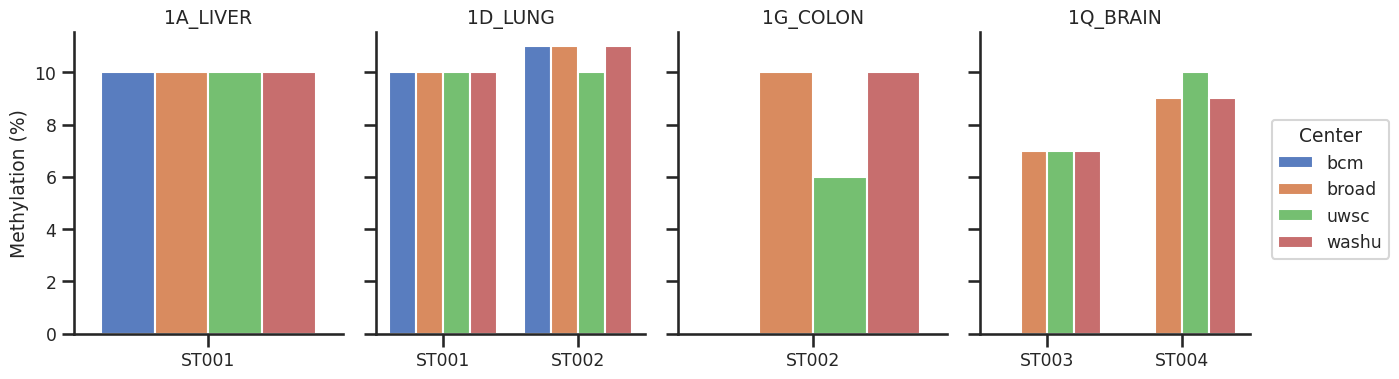

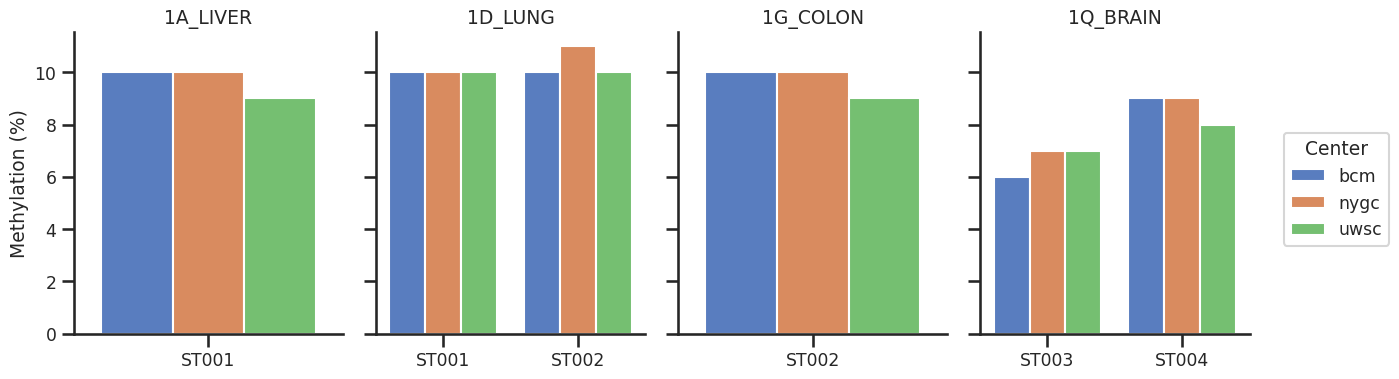

In [95]:
sns.set_theme(style="ticks", context="talk", font_scale=0.75)

g = sns.catplot(
    data=counts[counts['Seq_Tech'] == 'pacbio'],
    x="Donor",
    y="nunique_numts",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=counts[counts['Seq_Tech'] == 'ont'],
    x="Donor",
    y="nunique_numts",
    col="Tissue",
    #col='Seq_Tech',    
    hue="Center",
    kind="bar",
    height=4,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharey=True,
    sharex=False,
    
)

sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5))
g.set_titles("{col_name}")
g.set_axis_labels("", "Methylation (%)")
plt.tight_layout()
plt.show()

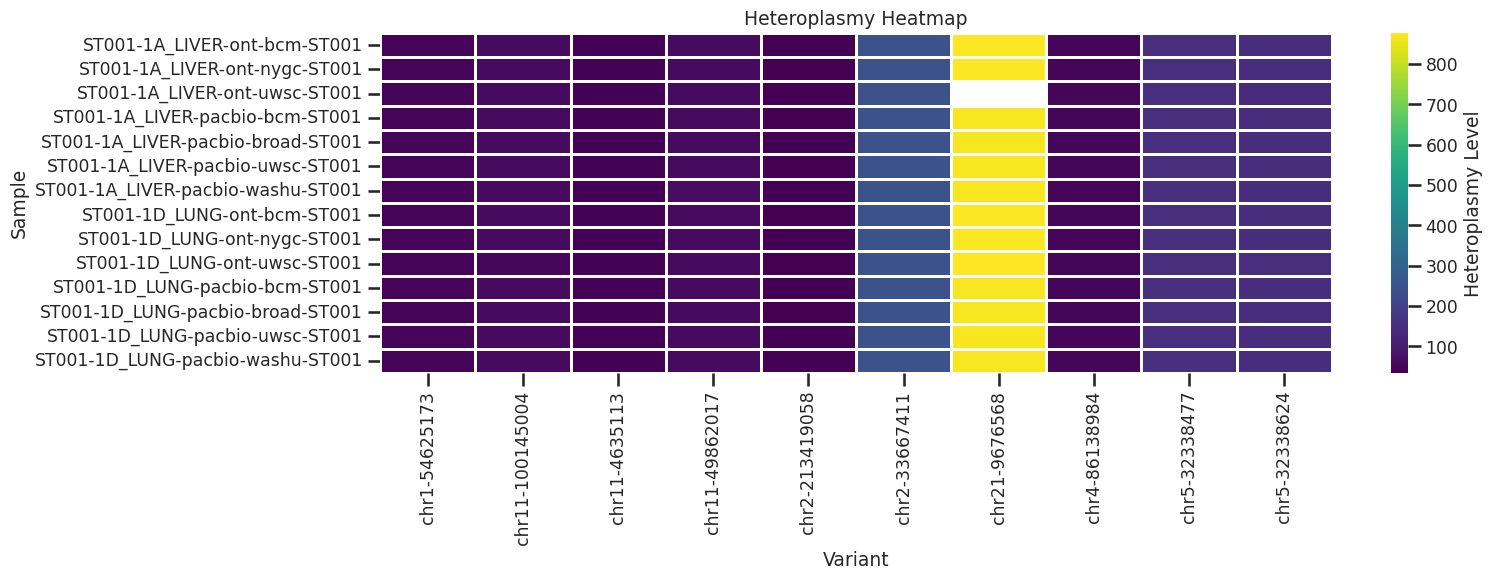

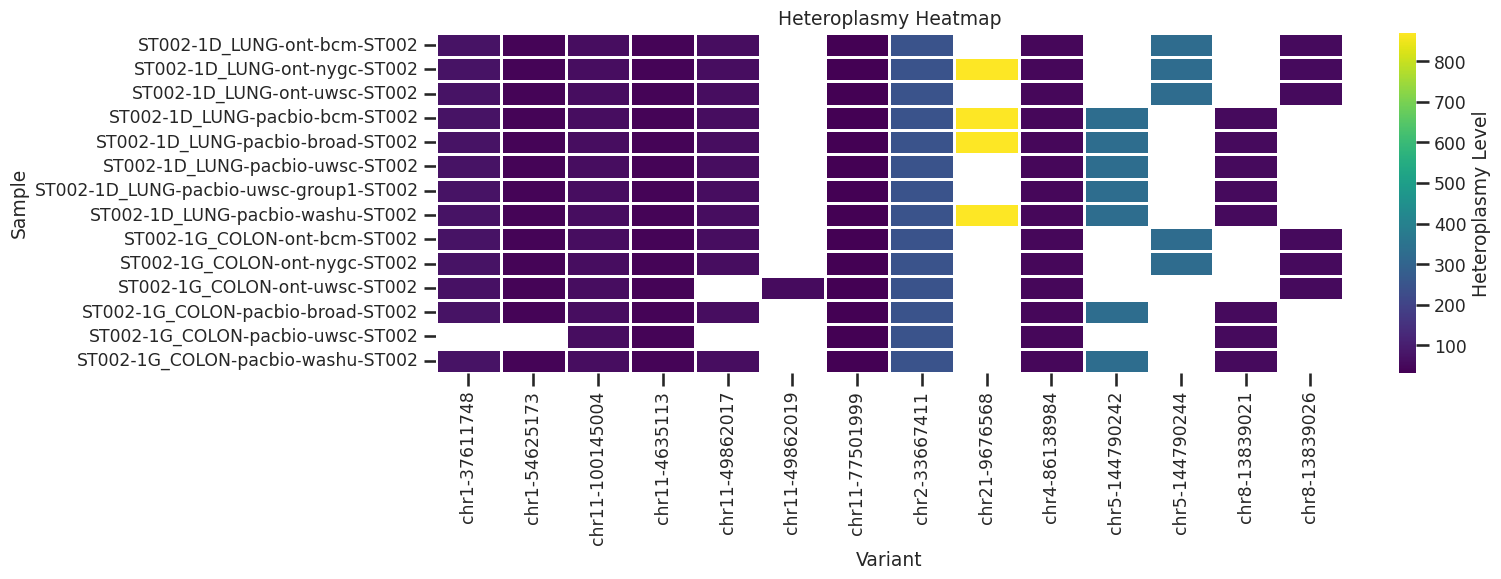

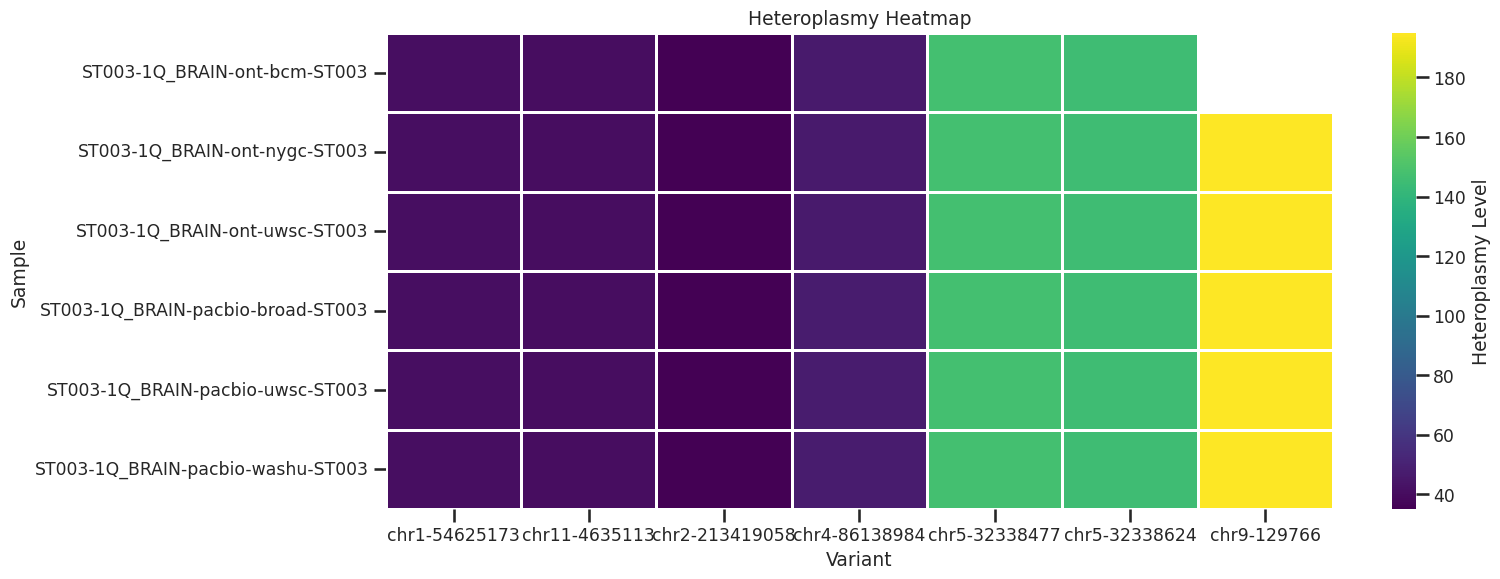

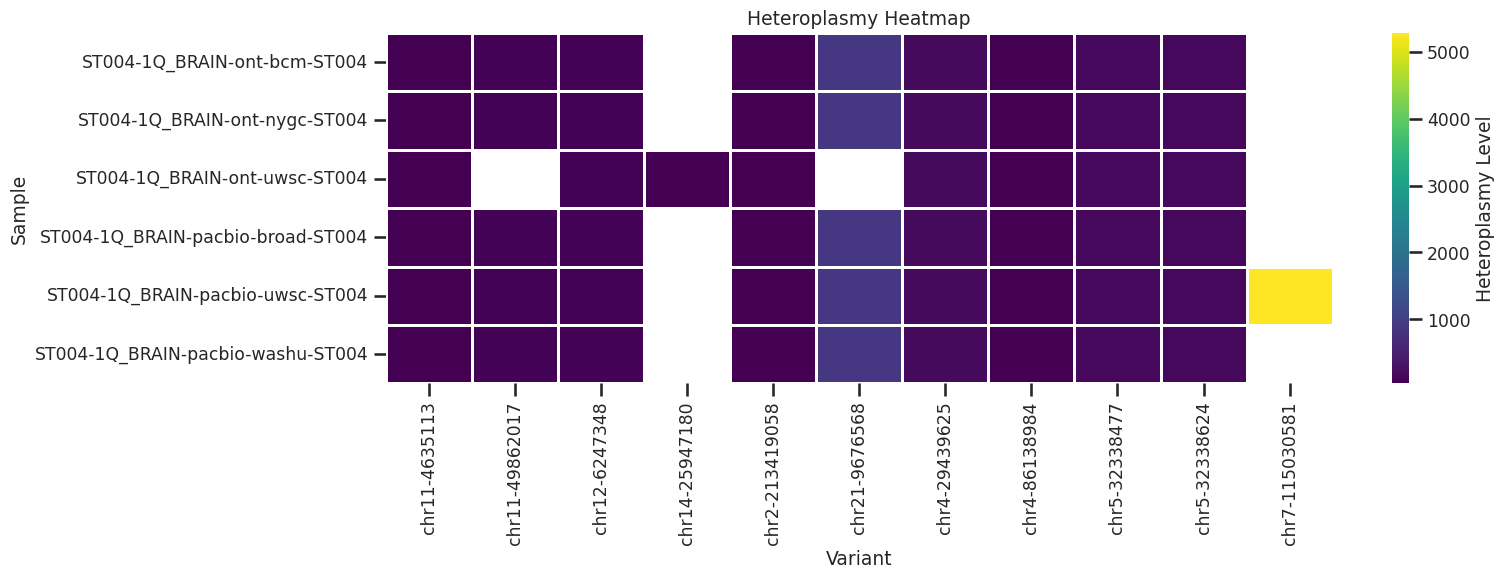

In [ ]:

donors = ['ST001', 'ST002', 'ST003', 'ST004']

comb_numt_df

for d in comb_numt_df['Donor+Tissue']:

    heatmap_data = comb_numt_df[comb_numt_df['Donor'] == d].pivot(index=['Sample','Donor'], columns='id', values='length')

    # Sort columns by highest average AF
    #column_order = heatmap_data.mean(axis=0).sort_values(ascending=False).index
    #heatmap_data = heatmap_data[column_order]

    # Plot heatmap
    plt.figure(figsize=(16, 6))
    sns.heatmap(heatmap_data, cmap="viridis", linewidths=1,annot=False, cbar_kws={'label': 'Heteroplasmy Level'})
    plt.title('Heteroplasmy Heatmap')
    plt.xlabel('Variant')
    plt.ylabel('Sample')
    plt.tight_layout()
    plt.show()
